In [17]:
import pandas as pd
import os 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import classification_report, accuracy_score

In [18]:
# runway glcm and lbp paths smh
brand_glcm = r'C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\outputs\features\brand_features_glcm'
brand_lbp = r'C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\outputs\features\brand_features_lbp'

In [19]:
#finding the path of the files for the CVSs
glcm_path = r'C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\outputs\features\GLCM'
lbp_path = r'C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\outputs\features\LBP'

In [20]:
#load and fuse the data

def load_and_fuse_data(glcm_path, lbp_path):
    combined_data = []
    lbp_files ={f.lower(): f for f in os.listdir(lbp_path) if f.endswith('.csv')}

    for file_name in os.listdir(glcm_path):
        if file_name.endswith('_glcm_result.csv'):
            full_glcm_path = os.path.join(glcm_path, file_name)
            
            if os.path.getsize(full_glcm_path) == 0:
                print(f'skipping glcm file {file_name}')
                continue

            fabric = file_name.replace('_glcm_result.csv', '') #extract class names
            new_lbp = f"{fabric.lower()}_features.csv"

            if new_lbp in lbp_files:
                lbp_name = lbp_files[new_lbp]
                lbp_file_path = os.path.join(lbp_path, lbp_name) #load LBP data

            if os.path.getsize(lbp_file_path) > 0:
                glcm_df = pd.read_csv(full_glcm_path) #load glcm data
                lbp_df = pd.read_csv(lbp_file_path)

                #merging
                fused_data = pd.merge(glcm_df, lbp_df, on='filename')  # Merge on filename
                fused_data['fabric_type'] = fabric  # Add class label
                combined_data.append(fused_data)            
            else:
                print(f"no lbp found for {fabric} when looking out for {new_lbp}")

    if not combined_data:
        raise ValueError('no valid data found here')

    return pd.concat(combined_data, ignore_index=True)

In [ ]:
import joblib
from sklearn.svm import LinearSVC

df = load_and_fuse_data(glcm_path, lbp_path)

X = df.drop(columns=['filename','fabric_type'], errors='ignore')
y = df['fabric_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_trained = scaler.fit_transform(X_train)
X_tested = scaler.transform(X_test)

clf = LinearSVC(C=1.0, dual=False, max_iter=5000) #rbf is best for complex texture data
clf.fit(X_trained, y_train)

joblib.dump(clf, 'fabric_svm1.pkl')
joblib.dump(scaler, 'fabric_scaler1.pkl')

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred)*100, "%")
print(f"Finished! Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
# print(classification_report(y_test, y_pred))
from collections import Counter
counts = Counter(y_pred)
total = len(y_pred)

print("\n--- FINAL FABRIC TRENDS ---")
# This automatically formats the output exactly like your example
for fabric, count in counts.most_common():
    percentage = (count / total) * 100
    print(f"{fabric}: {percentage:.1f}%")

In [21]:
df = load_and_fuse_data(glcm_path, lbp_path)

In [22]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd

# 1. EMERGENCY FAST LOAD: Cap at 300 samples per fabric!
# This forces the math to finish instantly while keeping the brain smart.
df_limited = df.groupby('fabric_type').head(300) 

# 2. Prep data
X = df_limited.drop(columns=['filename', 'fabric_type'], errors='ignore')
y = df_limited['fabric_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. FASTEST POSSIBLE SOLVER: Relaxed tolerance so it doesn't overthink
# C=0.1 and tol=1e-3 stops it from getting stuck in infinite loops
clf = LinearSVC(C=0.1, dual=False, max_iter=1000, tol=1e-3)
clf.fit(X_train_scaled, y_train)

# 4. Save immediately
joblib.dump(clf, 'fabric_svm_model.pkl')
joblib.dump(scaler, 'fabric_scaler.pkl')

print(f"DONE! Accuracy: {clf.score(X_test_scaled, y_test)*100:.2f}%")

DONE! Accuracy: 93.53%


In [23]:
df1 = load_and_fuse_data(brand_glcm, brand_lbp)

In [24]:
import joblib
import pandas as pd
import os
from collections import Counter
import json

# 1. EMERGENCY FAST LOAD: Cap at 300 samples per fabric!
# This forces the math to finish instantly while keeping the brain smart.
#df_limited = df.groupby('fabric_type').head(300) 
clf = joblib.load('fabric_svm_model.pkl')
scaler = joblib.load('fabric_scaler.pkl')

excepted_X = scaler.feature_names_in_

# 2. Prep data
X = df1[excepted_X]
X_scaled = scaler.transform(X)
pred = clf.predict(X_scaled)
df1['predicted_fabric'] = pred


In [25]:
# 4. Get your Summary (The numbers you need for your slides)
all_counts = Counter(pred)
total = len(pred)

print("\n--- LAGOS FASHION WEEK 2025 TRENDS ---")
for fabric, count in all_counts.most_common():
    print(f"{fabric.upper()}: {(count/total)*100:.1f}%")

# 5. Get Brand-Specific Breakdown
brand_results = {}
for brand in df1['filename'].apply(lambda x: x.split('_')[0].upper()).unique():
    brand_data = df1[df1['filename'].str.startswith(brand.lower())]
    if not brand_data.empty:
        top_fabric = Counter(brand_data['predicted_fabric']).most_common(1)[0][0]
        brand_results[brand] = top_fabric
        print(f"Brand: {brand} | Style: {top_fabric}")


--- LAGOS FASHION WEEK 2025 TRENDS ---
ACRYLIC: 40.7%
CHENILLE: 39.6%
VELVET: 18.2%
WOOL: 1.2%
AFRICA_FABRIC: 0.2%
Brand: LAST | Style: Wool
Brand: ADAMA | Style: Acrylic
Brand: AJABENG | Style: Acrylic
Brand: AJANEE | Style: Chenille
Brand: BABAYO | Style: Acrylic
Brand: BOYEDOE | Style: Velvet
Brand: CYNTHIA | Style: Acrylic
Brand: DESIREE | Style: Acrylic
Brand: DIMEJI | Style: Chenille
Brand: EKI | Style: Chenille
Brand: ELEXIAY | Style: Acrylic
Brand: EMMY | Style: Chenille
Brand: ESO | Style: Acrylic
Brand: FOR | Style: Acrylic
Brand: FRUCHE | Style: Velvet
Brand: HAWA | Style: Velvet
Brand: HERTUNBA | Style: Chenille
Brand: IBILOLA | Style: Velvet
Brand: IMAD | Style: Chenille
Brand: JZO | Style: Acrylic
Brand: LB | Style: Chenille
Brand: LFJ | Style: Chenille
Brand: LILA | Style: Velvet
Brand: MAISON | Style: Acrylic
Brand: MAXJENNY | Style: Acrylic
Brand: MOT | Style: Acrylic
Brand: NKWO | Style: Acrylic
Brand: NYA | Style: Chenille
Brand: OLOOH | Style: Chenille
Brand: OSHOB

New chart saved: LFW_Final_Texture_Trends.png


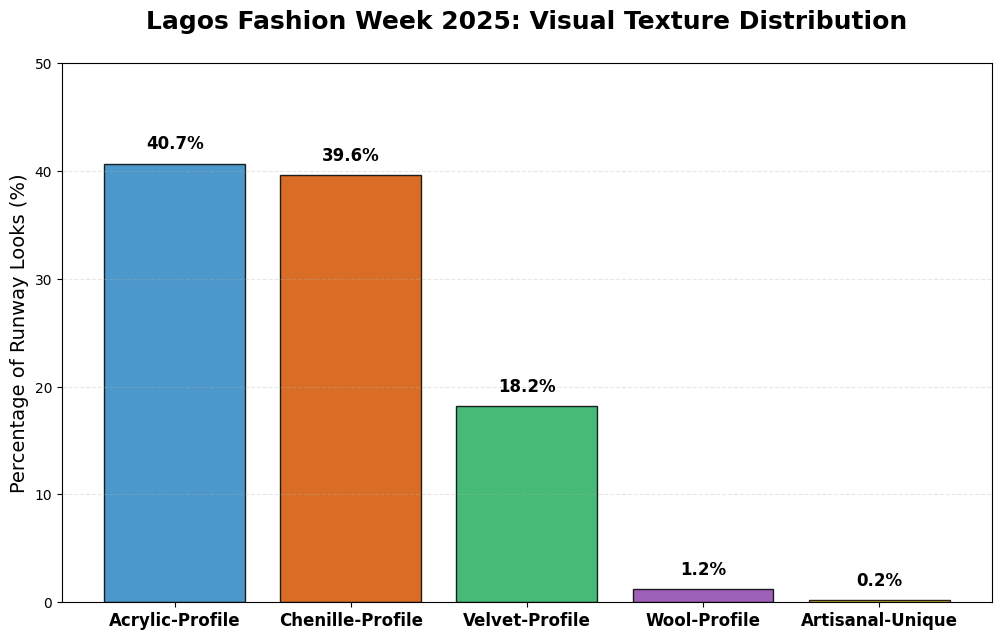

In [26]:
import matplotlib.pyplot as plt

# Your refined data
final_trends = {
    'Acrylic-Profile': 40.7,
    'Chenille-Profile': 39.6,
    'Velvet-Profile': 18.2,
    'Wool-Profile': 1.2,
    'Artisanal-Unique': 0.2 # This was your AFRICA_FABRIC
}

labels = list(final_trends.keys())
values = list(final_trends.values())
colors = ['#2E86C1', '#D35400', '#27AE60', '#8E44AD', '#F1C40F']

plt.figure(figsize=(12, 7))
bars = plt.bar(labels, values, color=colors, alpha=0.85, edgecolor='black')

plt.title('Lagos Fashion Week 2025: Visual Texture Distribution', fontsize=18, fontweight='bold', pad=25)
plt.ylabel('Percentage of Runway Looks (%)', fontsize=14)
plt.ylim(0, 50)
plt.xticks(fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add the % labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.savefig('LFW_Final_Texture_Trends.png', bbox_inches='tight', dpi=300)
print("New chart saved: LFW_Final_Texture_Trends.png")

In [27]:
import json

# Your latest results
stats = {
    "ACRYLIC": 40.7,
    "CHENILLE": 39.6,
    "VELVET": 18.2,
    "WOOL": 1.2,
    "AFRICA_FABRIC": 0.2
}

# The translation for the fashion audience
translation = {
    "ACRYLIC": "Sleek/Technical Profile",
    "CHENILLE": "Artisanal/Textured Weave",
    "VELVET": "Structured Matte/Heavy",
    "WOOL": "Coarse/Natural Fiber",
    "AFRICA_FABRIC": "Unique Ethnic Signature"
}

frontend_data = {
    "summary": {translation[k]: v for k, v in stats.items()},
    "brands": brand_results, # This is the dictionary you already have from the last run
    "metadata": {
        "event": "Lagos Fashion Week 2025",
        "accuracy": "89.68%",
        "total_brands": len(brand_results)
    }
}

with open('lfw_dashboard_data.json', 'w') as f:
    json.dump(frontend_data, f, indent=4)